# Experiment 3.0.6 — Frozen Causal Temporal Decoding

Analysis-only notebook. Causal heads are fit in independent Slurm tasks; this notebook only reads finalized artifacts.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

REPO_ROOT = find_repo_root()
ROOT = REPO_ROOT / 'notebooks/artifacts/experiment_3_0_6_causal_temporal_decoding/frozen_causal_v1'
ROOT

PosixPath('/home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_3_0_6_causal_temporal_decoding/frozen_causal_v1')

In [2]:
summary = pd.read_csv(ROOT / 'experiment_3_0_6_summary.csv')
curves = pd.read_csv(ROOT / 'experiment_3_0_6_curves.csv')
selection = pd.read_csv(ROOT / 'experiment_3_0_6_validation_selection.csv')
with (ROOT / 'selected_causal_decoder.json').open() as f:
    selected = json.load(f)
display(summary)
display(selection)
selected

,decoder,mean_val_early_recognition_auc,sd_val_early_recognition_auc,mean_test_early_recognition_auc,sd_test_early_recognition_auc,mean_test_final_ba,sd_test_final_ba,mean_t90_ms,mean_t95_ms
0,cumulative250,0.421469,0.013086,0.465057,0.023689,0.541111,0.025230,1416.666667,1500.000000
1,current250,0.364449,0.019467,0.331657,0.001558,0.342602,0.008372,833.333333,833.333333
2,native_timestep,0.414680,0.013898,0.424717,0.021910,0.492621,0.021025,1416.666667,1583.333333
3,prefix250_uniform,0.441387,0.000218,0.506339,0.007119,0.590374,0.014055,1416.666667,1583.333333
4,prefix250_weighted,0.462856,0.020717,0.523202,0.023458,0.616347,0.028169,1416.666667,1500.000000


,decoder,mean_val_early_recognition_auc
0,prefix250_weighted,0.462856
1,prefix250_uniform,0.441387
2,cumulative250,0.421469
3,current250,0.364449


{'experiment_id': 'experiment_3_0_6_causal_temporal_decoding',
 'protocol_version': 'frozen_causal_v1',
 'seeds': [11, 23, 101],
 'selected_decoder': 'prefix250_weighted',
 'selection_metric': 'mean validation Early Recognition AUC',
 'source_objective': 'timestep_ce',
 'tie_breaker': 'decoder name only; test metrics are never used for selection'}

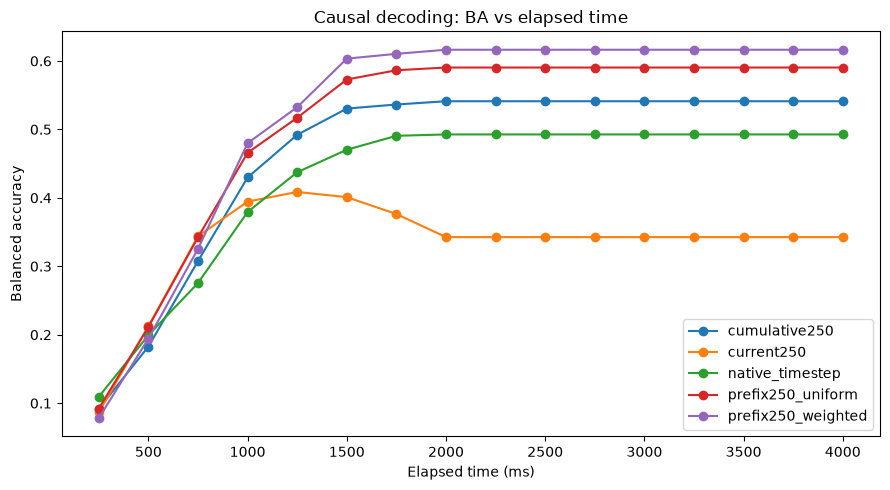

In [3]:
test = curves[curves['split'] == 'test']
mean_curve = test.groupby(['decoder', 'elapsed_ms'], as_index=False)['balanced_accuracy'].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for decoder, group in mean_curve.groupby('decoder'):
    ax.plot(group['elapsed_ms'], group['balanced_accuracy'], marker='o', label=decoder)
ax.set_xlabel('Elapsed time (ms)')
ax.set_ylabel('Balanced accuracy')
ax.set_title('Causal decoding: BA vs elapsed time')
ax.legend()
plt.tight_layout()
plt.show()